In [ ]:
import pandas as pd
import numpy as np

print("Ready")

Ready


In [ ]:
import pandas as pd

df = pd.read_csv("delivery_time_dirty_dataset.csv")

df.head()

,order_id,distance_km,weather,traffic_level,restaurant_load,courier_experience_years,hour,weekday,delivery_time_min
0,1,8.12,snow,medium,medium,5.4,23,3,44.3
1,2,19.06,NaN,low,medium,8.4,1,0,81.4
2,3,14.91,Sunny,HIGH,low,7.5,1,5,54.6
3,4,12.37,snow,medium,high,3.0,22,3,72.7
4,5,3.96,RAIN,medium,low,0.7,14,4,26.2


In [ ]:
df.shape

(5000, 9)

In [ ]:
df.dtypes

,0
order_id,int64
distance_km,float64
weather,object
traffic_level,object
restaurant_load,object
courier_experience_years,float64
hour,int64
weekday,int64
delivery_time_min,float64


In [ ]:
df.describe()

,order_id,distance_km,courier_experience_years,hour,weekday,delivery_time_min
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,10.439806,5.333620,11.612200,3.039800,40.311480
std,1443.520003,5.503101,2.743808,6.892149,2.008836,19.924916
min,1.000000,1.000000,0.500000,0.000000,0.000000,5.000000
25%,1250.750000,5.637500,3.000000,6.000000,1.000000,24.800000
50%,2500.500000,10.500000,5.400000,12.000000,3.000000,40.100000
75%,3750.250000,15.212500,7.700000,18.000000,5.000000,55.300000
max,5000.000000,19.990000,10.000000,23.000000,6.000000,110.400000


In [ ]:
df.isnull().sum()

,0
order_id,0
distance_km,0
weather,150
traffic_level,152
restaurant_load,0
courier_experience_years,149
hour,0
weekday,0
delivery_time_min,0


In [ ]:
df.duplicated().sum()

np.int64(50)

In [ ]:
df["weather"].unique()

array(['snow', nan, 'Sunny', 'RAIN', 'rain', 'sunny'], dtype=object)

In [ ]:
df["traffic_level"].unique()

array(['medium', 'low', 'HIGH', 'high', nan], dtype=object)

In [ ]:
df["weather"] = df["weather"].str.lower()

df["traffic_level"] = df["traffic_level"].str.lower()

In [ ]:
df["weather"].unique()

array(['snow', nan, 'sunny', 'rain'], dtype=object)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
order_id,0
distance_km,0
weather,150
traffic_level,150
restaurant_load,0
courier_experience_years,149
hour,0
weekday,0
delivery_time_min,0


In [ ]:
df["weather"].mode()

,weather
0,rain


In [ ]:
df["weather"] = df["weather"].fillna(
    df["weather"].mode()[0]
)

In [ ]:
df["traffic_level"] = df["traffic_level"].fillna(
    df["traffic_level"].mode()[0]
)

In [ ]:
df["courier_experience_years"].median()

5.3

In [ ]:
df["courier_experience_years"] = (
    df["courier_experience_years"].fillna(
        df["courier_experience_years"].median()
    )
)

In [ ]:
df.isnull().sum()

,0
order_id,0
distance_km,0
weather,0
traffic_level,0
restaurant_load,0
courier_experience_years,0
hour,0
weekday,0
delivery_time_min,0


In [ ]:
df["courier_experience_years"].min()

-5.0

In [ ]:
df[df["courier_experience_years"] < 0]

,order_id,distance_km,weather,traffic_level,restaurant_load,courier_experience_years,hour,weekday,delivery_time_min
814,815,17.53,rain,high,high,-5.0,8,1,88.6
1585,1586,3.59,snow,high,medium,-5.0,18,1,43.5
1596,1597,6.21,sunny,medium,high,-5.0,1,5,45.6
1824,1825,13.23,rain,low,low,-5.0,4,4,47.4
2873,2874,8.97,rain,high,high,-5.0,15,3,63.8
2884,2885,2.31,sunny,high,medium,-5.0,21,4,23.6
3761,3762,14.96,snow,medium,high,-5.0,20,0,71.8
3768,3769,4.12,sunny,high,low,-5.0,12,3,19.1
4163,4164,8.22,rain,high,medium,-5.0,1,6,54.7
4561,4562,6.46,snow,high,medium,-5.0,15,5,55.4


In [ ]:
df = df[df["courier_experience_years"] >= 0]

In [ ]:
df["courier_experience_years"].min()

0.5

In [ ]:
df["distance_km"].max()

295.0819816113188

In [ ]:
df[df["distance_km"] > 50]

,order_id,distance_km,weather,traffic_level,restaurant_load,courier_experience_years,hour,weekday,delivery_time_min
431,432,177.142261,sunny,high,high,5.1,18,3,66.0
706,707,177.188177,rain,high,medium,2.2,6,6,47.4
1009,1010,132.280836,sunny,low,medium,2.9,0,4,36.4
1073,1074,261.010161,sunny,medium,medium,7.4,13,5,17.2
1263,1264,179.392410,snow,medium,low,4.1,8,2,52.0
1462,1463,133.706131,sunny,high,low,5.8,4,1,17.5
1551,1552,143.357490,sunny,high,medium,9.1,5,1,43.5
1607,1608,128.775883,rain,low,high,1.2,3,0,79.2
1638,1639,295.081982,sunny,medium,medium,5.3,3,2,61.9
1836,1837,277.294169,snow,high,low,5.5,22,0,50.0


In [ ]:
df = df[df["distance_km"] <= 50]

In [ ]:
df["distance_km"].max()

19.99

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

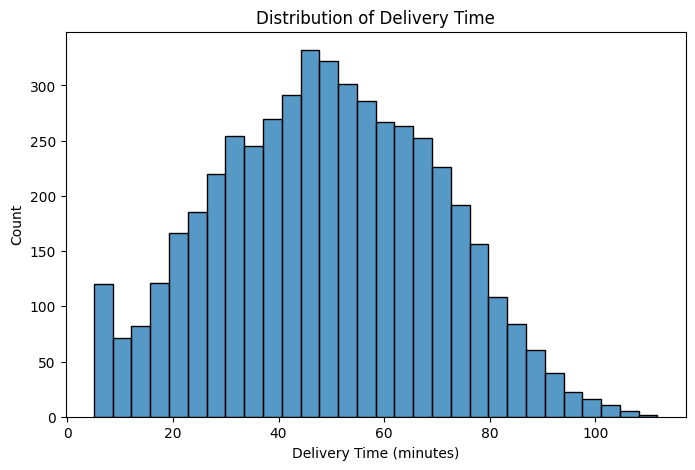

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["delivery_time_min"], bins=30)

plt.title("Distribution of Delivery Time")

plt.xlabel("Delivery Time (minutes)")

plt.ylabel("Count")

plt.show()

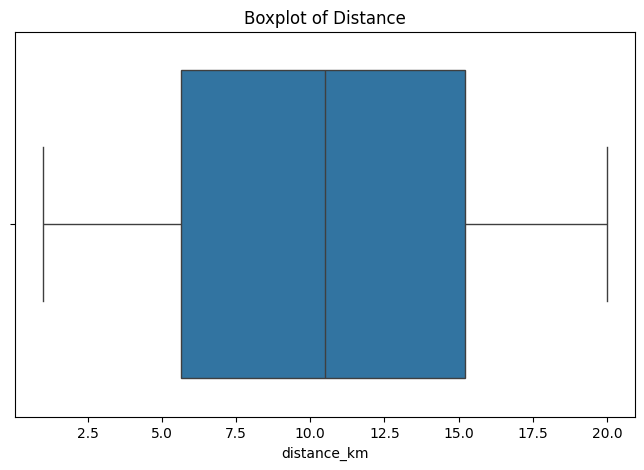

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["distance_km"])

plt.title("Boxplot of Distance")

plt.show()

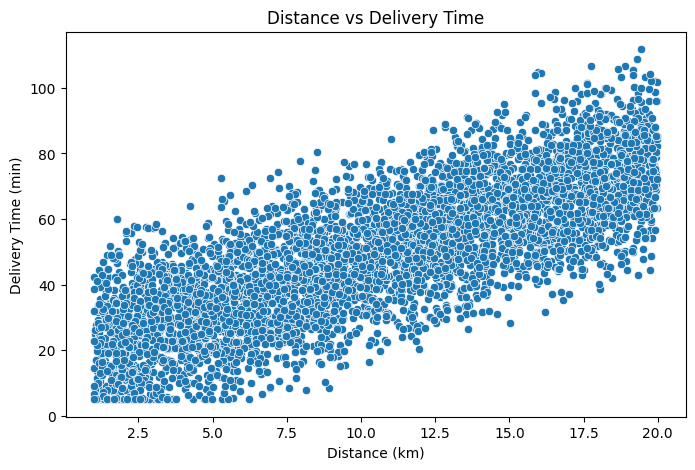

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["distance_km"],
    y=df["delivery_time_min"]
)

plt.title("Distance vs Delivery Time")

plt.xlabel("Distance (km)")

plt.ylabel("Delivery Time (min)")

plt.show()

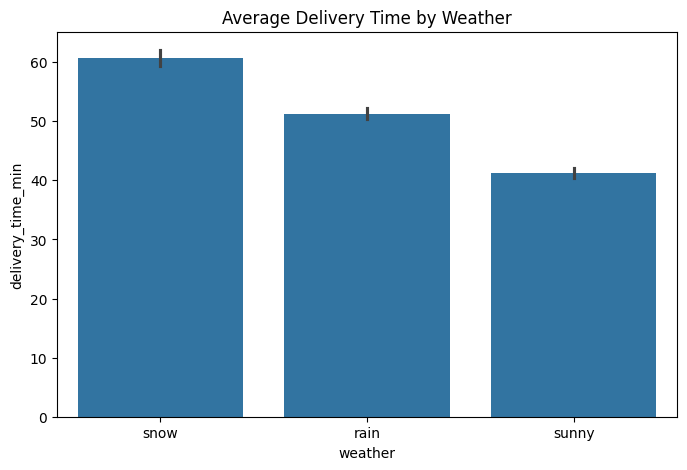

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=df["weather"],
    y=df["delivery_time_min"]
)

plt.title("Average Delivery Time by Weather")

plt.show()

In [ ]:
X = df.drop("delivery_time_min", axis=1)

y = df["delivery_time_min"]

In [ ]:
X.head()

,order_id,distance_km,weather,traffic_level,restaurant_load,courier_experience_years,hour,weekday
0,1,8.12,snow,medium,medium,5.4,23,3
1,2,19.06,rain,low,medium,8.4,1,0
2,3,14.91,sunny,high,low,7.5,1,5
3,4,12.37,snow,medium,high,3.0,22,3
4,5,3.96,rain,medium,low,0.7,14,4


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3976, 11)
X_test: (994, 11)
y_train: (3976,)
y_test: (994,)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred[:10])

[34.40942685 29.1446904  25.71167621 78.96859259 69.34209775 42.80634862
 63.8938281  36.18088493 45.7291099  49.5422248 ]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 4.2959144550935875


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 5.380515554721816


In [ ]:
r2 = r2_score(y_test, y_pred)

print("R2:", r2)

R2: 0.9332176271039775


In [ ]:
model.coef_

array([-4.89618145e-05,  2.99538442e+00, -1.19766816e+00,  7.53757724e-03,
       -1.26620334e-02,  1.01634443e+01, -9.81952470e+00, -1.43989340e+01,
       -9.44173159e+00, -1.45949451e+01, -7.98156069e+00])

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

feature_importance

,feature,coefficient
0,order_id,-0.000049
1,distance_km,2.995384
2,courier_experience_years,-1.197668
3,hour,0.007538
4,weekday,-0.012662
5,weather_snow,10.163444
6,weather_sunny,-9.819525
7,traffic_level_low,-14.398934
8,traffic_level_medium,-9.441732
9,restaurant_load_low,-14.594945


In [ ]:
feature_importance = feature_importance.sort_values(
    by="coefficient",
    ascending=False
)

feature_importance

,feature,coefficient
5,weather_snow,10.163444
1,distance_km,2.995384
3,hour,0.007538
0,order_id,-0.000049
4,weekday,-0.012662
2,courier_experience_years,-1.197668
10,restaurant_load_medium,-7.981561
8,traffic_level_medium,-9.441732
6,weather_sunny,-9.819525
7,traffic_level_low,-14.398934


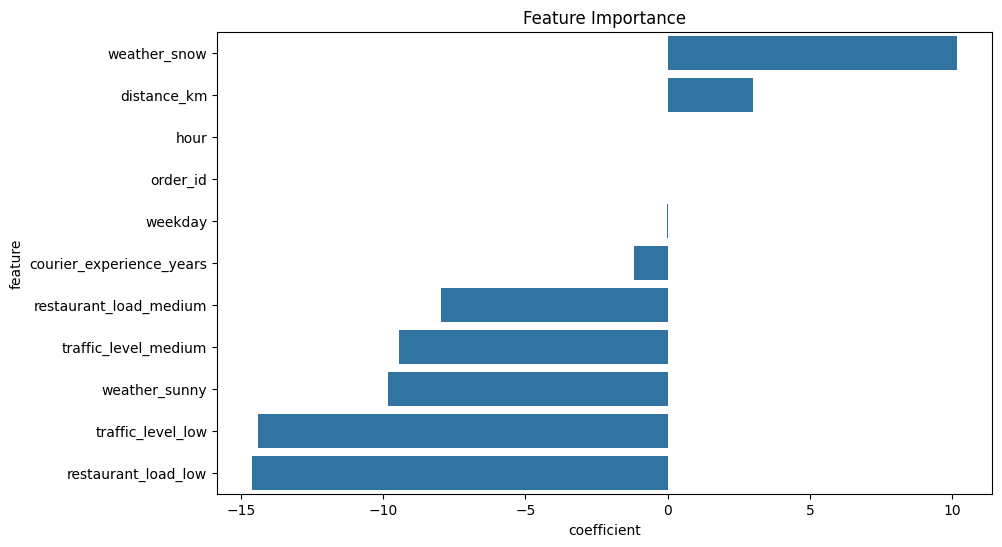

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="coefficient",
    y="feature"
)

plt.title("Feature Importance")

plt.show()

In [ ]:
results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

results.head(10)

,actual,predicted
859,22.3,34.409427
3679,30.6,29.144690
4630,16.5,25.711676
4395,76.5,78.968593
3893,64.1,69.342098
2310,46.2,42.806349
4266,67.3,63.893828
2651,38.3,36.180885
350,57.8,45.729110
3036,48.9,49.542225


In [ ]:
results["error"] = abs(
    results["actual"] - results["predicted"]
)

results.head(10)

,actual,predicted,error
859,22.3,34.409427,12.109427
3679,30.6,29.144690,1.455310
4630,16.5,25.711676,9.211676
4395,76.5,78.968593,2.468593
3893,64.1,69.342098,5.242098
2310,46.2,42.806349,3.393651
4266,67.3,63.893828,3.406172
2651,38.3,36.180885,2.119115
350,57.8,45.729110,12.070890
3036,48.9,49.542225,0.642225


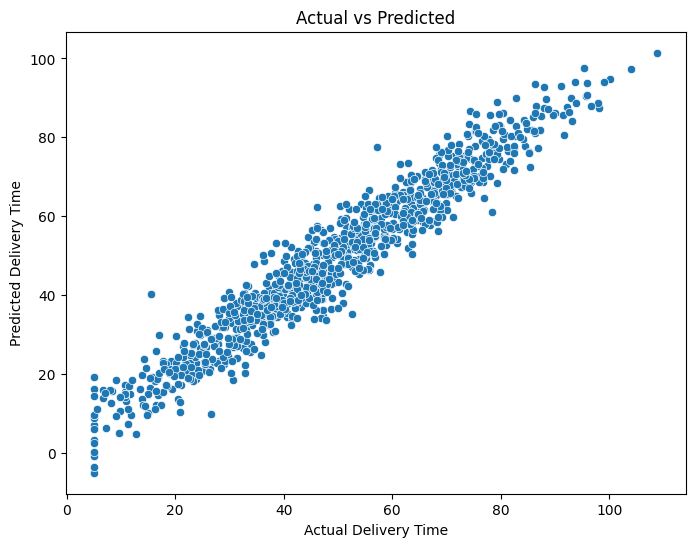

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=results["actual"],
    y=results["predicted"]
)

plt.xlabel("Actual Delivery Time")

plt.ylabel("Predicted Delivery Time")

plt.title("Actual vs Predicted")

plt.show()

In [ ]:
new_data = df.copy()

new_data["distance_km"] = (
    new_data["distance_km"] * 1.5
)

new_data["traffic_level"] = "high"

In [ ]:
new_delivery_time = (
    new_data["distance_km"] * 3
)

new_delivery_time += np.where(
    new_data["weather"] == "rain",
    10,
    0
)

new_delivery_time += np.where(
    new_data["weather"] == "snow",
    20,
    0
)

new_delivery_time += 15

new_delivery_time += np.where(
    new_data["restaurant_load"] == "medium",
    7,
    0
)

new_delivery_time += np.where(
    new_data["restaurant_load"] == "high",
    15,
    0
)

new_delivery_time -= (
    new_data["courier_experience_years"] * 1.2
)

new_data["delivery_time_min"] = new_delivery_time

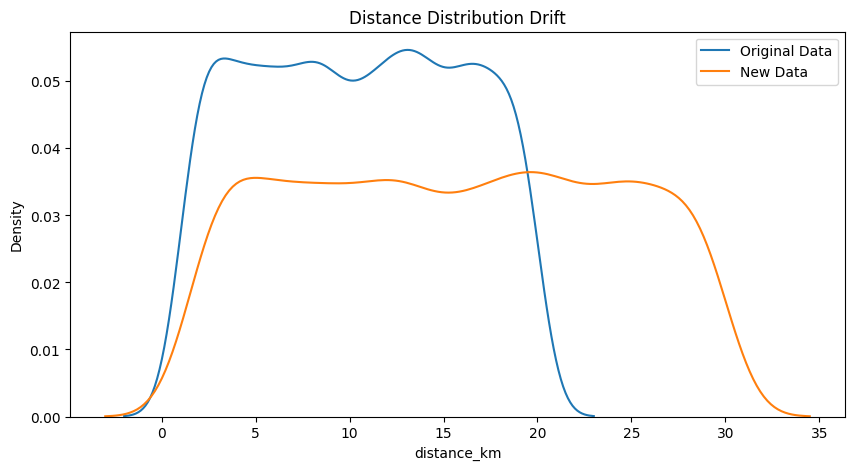

In [ ]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    df["distance_km"],
    label="Original Data"
)

sns.kdeplot(
    new_data["distance_km"],
    label="New Data"
)

plt.title("Distance Distribution Drift")

plt.legend()

plt.show()

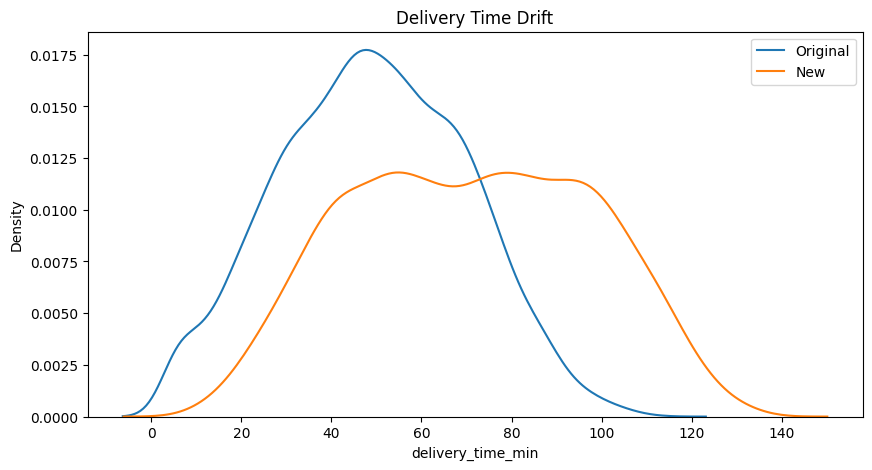

In [ ]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    df["delivery_time_min"],
    label="Original"
)

sns.kdeplot(
    new_data["delivery_time_min"],
    label="New"
)

plt.title("Delivery Time Drift")

plt.legend()

plt.show()

In [ ]:
import joblib

joblib.dump(model, "delivery_time_model.pkl")

['delivery_time_model.pkl']

In [ ]:
%%writefile app.py

import joblib
import pandas as pd
import streamlit as st

model = joblib.load("delivery_time_model.pkl")

st.title("Delivery Time Prediction")

st.write("This app predicts delivery time in minutes.")

distance_km = st.number_input("Distance in km", min_value=1.0, max_value=50.0, value=5.0)
courier_experience_years = st.number_input("Courier experience years", min_value=0.0, max_value=20.0, value=2.0)
hour = st.slider("Hour", 0, 23, 12)
weekday = st.slider("Weekday", 0, 6, 1)

weather = st.selectbox("Weather", ["sunny", "rain", "snow"])
traffic_level = st.selectbox("Traffic level", ["low", "medium", "high"])
restaurant_load = st.selectbox("Restaurant load", ["low", "medium", "high"])

input_data = pd.DataFrame({
    "order_id": [0],
    "distance_km": [distance_km],
    "courier_experience_years": [courier_experience_years],
    "hour": [hour],
    "weekday": [weekday],
    "weather_rain": [1 if weather == "rain" else 0],
    "weather_snow": [1 if weather == "snow" else 0],
    "traffic_level_low": [1 if traffic_level == "low" else 0],
    "traffic_level_medium": [1 if traffic_level == "medium" else 0],
    "restaurant_load_low": [1 if restaurant_load == "low" else 0],
    "restaurant_load_medium": [1 if restaurant_load == "medium" else 0],
})

input_data = input_data.reindex(
    columns=model.feature_names_in_,
    fill_value=0
)

if st.button("Predict"):
    prediction = model.predict(input_data)[0]
    st.success(f"Predicted delivery time: {prediction:.1f} minutes")

Overwriting app.py


In [ ]:
!pip install streamlit -q

In [ ]:
!streamlit run app.py



2026-05-11 03:28:36.557 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.135.11:8501

  Stopping...
  Stopping...
